In [1]:
import Gmsh: gmsh
import Pkg; Pkg.add("Distributions"); 
using Gridap, GridapGmsh
using Random
using Distributions
using Base.Threads
using LinearAlgebra
using Plots 

JULIA_NUM_THREADS=12
BLAS.set_num_threads(1)

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [35]:
function create_square_model(h)
    gmsh.initialize()
    gmsh.model.add("unit_square")
    gmsh.model.geo.addPoint(0,0,0,1,1) # last argument is optional identifier, unique per dimension
    gmsh.model.geo.addPoint(1,0,0,1,2)
    gmsh.model.geo.addPoint(1,1,0,1,3)
    gmsh.model.geo.addPoint(0,1,0,1,4)
    gmsh.model.geo.addLine(1,2,1)
    gmsh.model.geo.addLine(2,3,2) # line 2 goes from point 2 to point 3
    gmsh.model.geo.addLine(3,4,3)
    gmsh.model.geo.addLine(4,1,4)
        
    gmsh.model.geo.addCurveLoop([1,2,3,4],1)
        
    gmsh.model.geo.addPlaneSurface([1],1)

    N = Int(round(1/h))  # number of elements per edge

    gmsh.model.geo.mesh.setTransfiniteCurve(1, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(2, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(3, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(4, N+1)

    #triangulation
    gmsh.model.geo.mesh.setTransfiniteSurface(1)

    gmsh.model.geo.synchronize()

    # Define physical groups without the string argument
    edges_tag = gmsh.model.addPhysicalGroup(1, [1, 2, 3, 4])   # edges
    corners_tag = gmsh.model.addPhysicalGroup(0, [1, 2, 3, 4]) # corners
    domain_tag = gmsh.model.addPhysicalGroup(2, [1])           # surface
    
    # Set names for the physical groups
    gmsh.model.setPhysicalName(1, edges_tag, "boundary")
    gmsh.model.setPhysicalName(0, corners_tag, "boundary")
    gmsh.model.setPhysicalName(2, domain_tag, "domain")
    gmsh.model.mesh.generate(2)

    model = GmshDiscreteModel(gmsh);
    gmsh.finalize();
    return model
end



create_square_model (generic function with 1 method)

In [36]:
h = 0.2; # target mesh size
model = create_square_model(h) # fix above function above using the tutorial
order = 1
reffe = ReferenceFE(lagrangian, Float64, order)
V = TestFESpace(model, reffe, conformity=:H1, dirichlet_tags="boundary")
U = TrialFESpace(V, 0.0)


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.00497383s, CPU 0.005905s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.00686903s, CPU 0.006876s)
Info    : 36 nodes 74 elements


TrialFESpace()

In [37]:
Ω = Triangulation(model)
dΩ = Measure(Ω, 2 * order)

GenericMeasure()

In [38]:
n=7
Δt, T = 2.0^(-n), 2*π/3 # time step, final time
num_steps = Int(round(T / Δt))

268

In [39]:
f(x) = x[1]*x[2]#x[1]*(1-x[1]) *x[2]*(1-x[2]) #sin(x[1]*pi)*sin(x[2]*pi)
fx = x->f(x) 

#105 (generic function with 1 method)

In [40]:
u₀ = x -> 0.0
v₀ = x -> 0.0

#109 (generic function with 1 method)

In [41]:
m(u, v) = ∫(u*v)dΩ
k(u, v) = ∫(∇(u) ⋅ ∇(v))dΩ

Mmat = assemble_matrix(m, U, V)
Kmat = assemble_matrix(k, U, V)

LHSpos = (2/Δt)*Mmat + (Δt/2)*Kmat
RHSpos = (2/Δt)*Mmat - (Δt/2)*Kmat

16×16 SparseArrays.SparseMatrixCSC{Float64, Int64} with 82 stored entries:
⎡⠻⣦⠳⣄⠀⠀⠀⠀⎤
⎢⠙⢦⠻⣦⠳⣄⠀⠀⎥
⎢⠀⠀⠙⢦⠻⣦⠳⣄⎥
⎣⠀⠀⠀⠀⠙⢦⠻⣦⎦

In [42]:
uh0 = interpolate_everywhere(u₀, U)   # U^0
vh0 = interpolate_everywhere(v₀, U)   # V^0

SingleFieldFEFunction():
 num_cells: 50
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 1805432214092833932

In [43]:
if !isdir("tmp") mkdir("tmp") end

createpvd("wave") do pvd
    pvd[0.0] = createvtk(Ω, "tmp/stoc_wavev2_0.vtu",
                         cellfields=["uh" => uh0, "vh" => vh0])

    # dof-vectors
    uvec = get_free_dof_values(uh0)  # U^0
    vvec = get_free_dof_values(vh0)  # V^0

    b(v) = ∫(fx*v)dΩ
    Fn = assemble_vector(b, V)
    
    for n in 1:(num_steps-1)
        t_n = n*Δt
        Δβ = rand(Normal(0,sqrt(Δt)))
        noise =  Δβ * Fn


        #Solve for U^n
        rhs_u = RHSpos * uvec + (2*Mmat)*vvec + 2*noise
        uvec_new = LHSpos \ rhs_u

        #update V^n
        rhs_v = Mmat*vvec - (Δt/2)*Kmat*(uvec_new + uvec) + noise
        #rhs_v = ((2/Δt) * M) * (uvec_new - uvec) - M*vvec -noise
        vvec_new = Mmat \ rhs_v

        uh = FEFunction(U, uvec_new)
        vh = FEFunction(U, vvec_new)
        
        #save
        vtufilename = "tmp/stoc_wavev2_$(n).vtu"
        pvd[t_n] = createvtk(Ω, vtufilename, cellfields=["uh" => uh, "vh" => vh])

        # update
        uvec = uvec_new
        vvec = vvec_new
    end
end

269-element Vector{String}:
 "wave.pvd"
 "tmp/stoc_wavev2_0.vtu"
 "tmp/stoc_wavev2_1.vtu"
 "tmp/stoc_wavev2_2.vtu"
 "tmp/stoc_wavev2_3.vtu"
 "tmp/stoc_wavev2_4.vtu"
 "tmp/stoc_wavev2_5.vtu"
 "tmp/stoc_wavev2_6.vtu"
 "tmp/stoc_wavev2_7.vtu"
 "tmp/stoc_wavev2_8.vtu"
 "tmp/stoc_wavev2_9.vtu"
 "tmp/stoc_wavev2_10.vtu"
 "tmp/stoc_wavev2_11.vtu"
 ⋮
 "tmp/stoc_wavev2_256.vtu"
 "tmp/stoc_wavev2_257.vtu"
 "tmp/stoc_wavev2_258.vtu"
 "tmp/stoc_wavev2_259.vtu"
 "tmp/stoc_wavev2_260.vtu"
 "tmp/stoc_wavev2_261.vtu"
 "tmp/stoc_wavev2_262.vtu"
 "tmp/stoc_wavev2_263.vtu"
 "tmp/stoc_wavev2_264.vtu"
 "tmp/stoc_wavev2_265.vtu"
 "tmp/stoc_wavev2_266.vtu"
 "tmp/stoc_wavev2_267.vtu"

## Convergence Testing ##

In [66]:
function EMpath_stoch(uh0, vh0, T, Nref, kappa, facLHS, facM, Mmat, Kmat, Fvec, rng)
    Dtref = T / Nref
    Dt = kappa * Dtref
    NN = div(Nref, kappa)
    #precompute to avoid doing it for every timestep
    a = 2 / Dt
    b = Dt / 2
    sqrtDtref = sqrt(Dtref)

    #copy uh0 and vh0 to avoid modifying the original
    uvec = copy(get_free_dof_values(uh0))
    vvec = copy(get_free_dof_values(vh0))

    #allocate memory for all the arrays in the loop to avoid allocating garbage every time step.
    uvec_new = similar(uvec)
    vvec_new = similar(vvec)

    Mu = similar(uvec)
    Ku = similar(uvec)
    Mv = similar(uvec)
    usum = similar(uvec)

    rhs_u = similar(uvec)
    rhs_v = similar(uvec)

    for n in 1:NN
        Δβ = 0.0
        @inbounds for r in 1:kappa
            Δβ += sqrtDtref * randn(rng)
        end

        #Mu = Mmat * uvec
        mul!(Mu, Mmat, uvec)

        #Ku = Kmat * uvec
        mul!(Ku, Kmat, uvec)

        #Mv = Mmat * vvec
        mul!(Mv, Mmat, vvec)

        #rhs_u = (2/Dt) * M*u - (Dt/2) * K*u + 2*M*v + 2*Δβ*F
        rhs_u = a .* Mu .- b .* Ku .+ 2.0 .* Mv .+ 2.0 .* Δβ .* Fvec

        copyto!(uvec_new, rhs_u)
        ldiv!(facLHS, uvec_new)

        #usum = uvec_new + uvec
        usum = uvec_new .+ uvec

        #Ku = Kmat * (uvec_new + uvec)
        mul!(Ku, Kmat, usum)

        #rhs_v = M*v - (Dt/2) * K*(u_new + u_old) + Δβ*F
        rhs_v = Mv .- b .* Ku .+ Δβ .* Fvec

        copyto!(vvec_new, rhs_v)
        ldiv!(facM, vvec_new)

        uvec, uvec_new = uvec_new, uvec
        vvec, vvec_new = vvec_new, vvec
    end

    return uvec
end

EMpath_stoch (generic function with 2 methods)

In [67]:
function runEMpath_stoch(uh0, vh0, T, Nref, kappas, Nsamp, Mmat, Kmat, Fvec)
    nk = length(kappas) #number of kappas
    Dtref = T / Nref #time step for reference
    ndofs = length(Fvec) #number of degrees of freedom

    partial_sums = [zeros(nk) for _ in 1:nthreads()] #one vector per thread to compute sum and avoid race conditions

    facM = lu(Mmat) #pre-LU factorizion of mass matrix

    #pre-LU factorize the LHS matrix of the ref
    Dt1 = Dtref
    LHSpos1 = (2 / Dt1) * Mmat + (Dt1 / 2) * Kmat
    facLHS1 = lu(LHSpos1)

    #pre-LU factorize the LHS matrix for the kappas
    facLHS_list = Vector{typeof(facLHS1)}(undef, nk)
    for (i, kappa) in enumerate(kappas)
        Dt = kappa * Dtref
        LHSpos = (2 / Dt) * Mmat + (Dt / 2) * Kmat
        facLHS_list[i] = lu(LHSpos)
    end

    @threads for samp in 1:Nsamp #parallelize over MC samples
        tid = threadid() #thread index
        local_sum = partial_sums[tid] #the threads own vecotr to compute sum later

        seed = 1337 + samp #every sample gets new seed

        rng1 = Xoshiro(seed) #changed to xoshiro instead of MarsenneTwister, since it should be slightly faster
        uref = EMpath_stoch_new(uh0, vh0, T, Nref, 1, facLHS1, facM, Mmat, Kmat, Fvec, rng1) #use the rng for the uref

        Merr = zeros(ndofs) #allocate vector to avoid new ones being created for every kappa 

        for (i, kappa) in enumerate(kappas)
            rng2 = Xoshiro(seed) #same seed for rng2
            u = EMpath_stoch_new(uh0, vh0, T, Nref, kappa, facLHS_list[i], facM, Mmat, Kmat, Fvec, rng2) #use rng2 
            
            #compute error
            erru = u - uref
            mul!(Merr, Mmat, erru) #Merr = Mmat * erru
            local_sum[i] += dot(erru, Merr) #add to threads own vector 
        end
    end

    #add all thread vectors to get final vector.
    S_u = zeros(nk)
    for ps in partial_sums
        S_u .+= ps
    end

    return sqrt.(S_u ./ Nsamp)
end

runEMpath_stoch (generic function with 1 method)

In [68]:
T = 2*pi/3
kappas = [2,4,8,16,32,64]
Nref = 2^10
Nsamp = 5000
b(v) = ∫(fx*v)dΩ
Fvec = assemble_vector(b, V)
@time begin
rms_u = runEMpath_stoch(uh0, vh0, T, Nref, kappas, Nsamp, Mmat, Kmat, Fvec)
end
Dtref = T / Nref
dts = kappas .* Dtref
println("number of threads:")
println(nthreads())

println("dt values:")
println(dts)

println("RMS errors:")
println(rms_u)

 52.430975 seconds (224.85 M allocations: 10.085 GiB, 32.08% gc time, 6372394 lock conflicts, 27.43% compilation time)
number of threads:
12
dt values:
[0.0040906154343617095, 0.008181230868723419, 0.016362461737446838, 0.032724923474893676, 0.06544984694978735, 0.1308996938995747]
RMS errors:
[0.00039002257371452507, 0.0010000825025739144, 0.002154213471393348, 0.0043415462073974195, 0.009124387311115598, 0.01821815729188866]


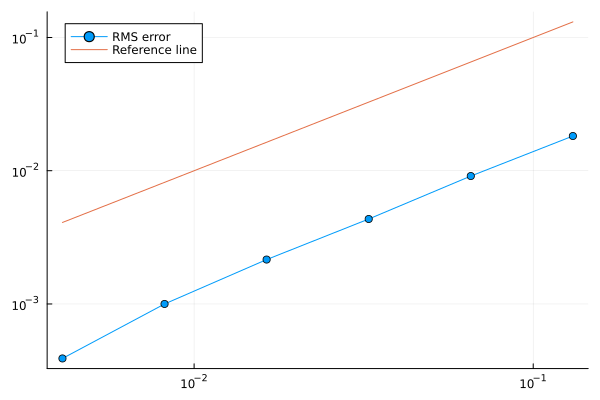

In [65]:
x = range(minimum(dts),maximum(dts), 100)
# log-log plot
plot(dts, rms_u, xaxis=:log, yaxis=:log, marker=:circle, label="RMS error")
plot!(x, x.^1, xaxis=:log, yaxis=:log, label="Reference line")